In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow
from tensorflow import keras

In [ ]:
student = pd.read_csv('/content/sample_data/cs_students.csv')
student.head()

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


In [ ]:
student.describe()

,Student ID,Age,GPA
count,180.000000,180.000000,180.000000
mean,90.500000,22.116667,3.615000
std,52.105662,2.823040,0.177341
min,1.000000,20.000000,3.200000
25%,45.750000,21.000000,3.500000
50%,90.500000,22.000000,3.600000
75%,135.250000,22.250000,3.700000
max,180.000000,37.000000,3.900000


In [ ]:
student.columns

Index(['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major',
       'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL',
       'Java'],
      dtype='object')

In [ ]:
student.isna().sum()

,0
Student ID,0
Name,0
Gender,0
Age,0
GPA,0
Major,0
Interested Domain,0
Projects,0
Future Career,0
Python,0


In [ ]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


In [ ]:
student.shape

(180, 12)

In [ ]:
student.duplicated().sum()

np.int64(0)

In [ ]:
useless_col = ['Student ID','Name','Major']
student.drop(columns = useless_col , inplace = True, errors='ignore')
student.head()

,Gender,Age,GPA,Interested Domain,Projects,Future Career,Python,SQL,Java
0,Male,21,3.5,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,Female,20,3.2,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,Male,22,3.8,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,Female,21,3.7,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,Male,23,3.4,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


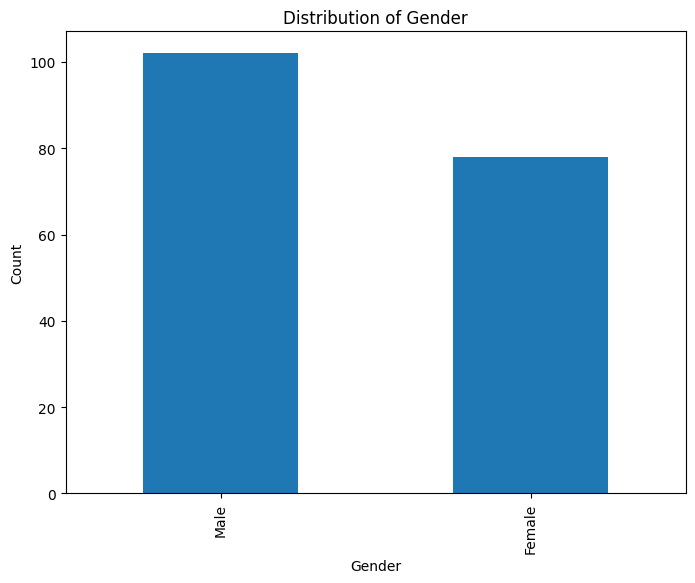

In [ ]:
student['Gender'].value_counts().plot(kind='bar', title='Distribution of Gender', figsize=(8, 6))
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

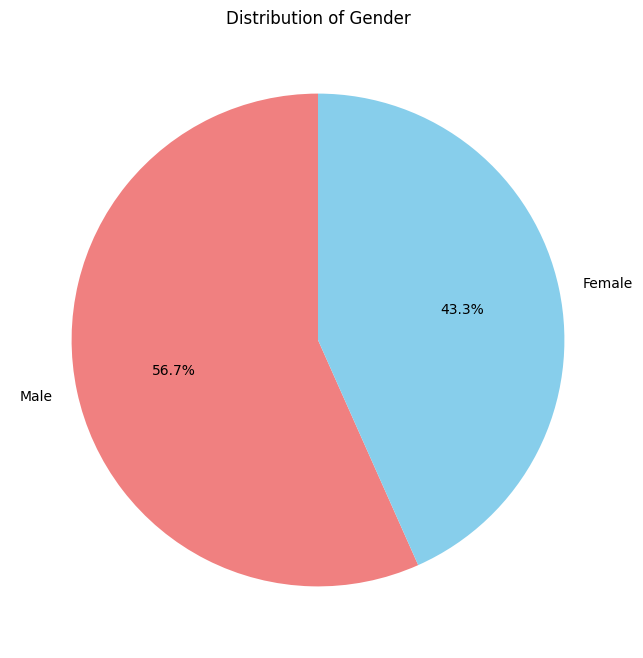

In [ ]:
gender_counts = student['Gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title('Distribution of Gender')

plt.show()

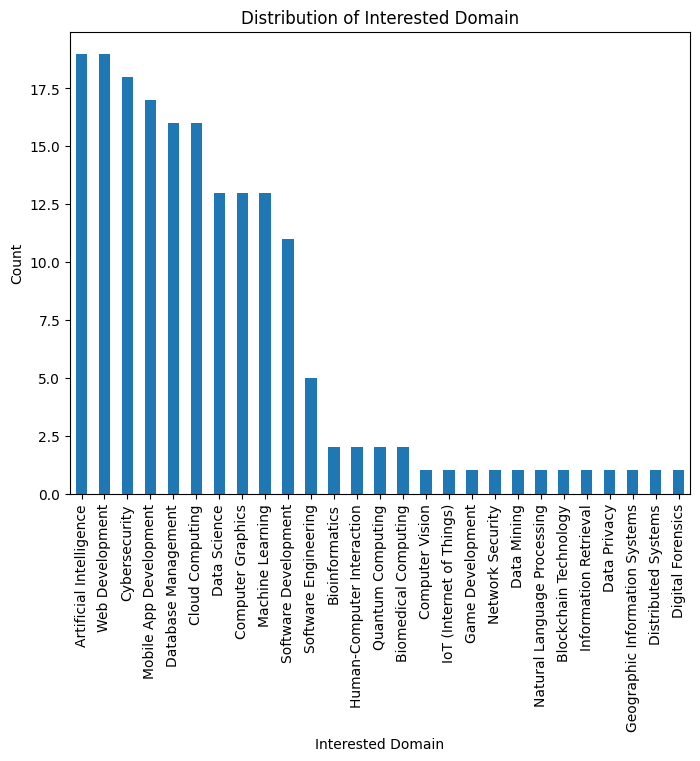

In [ ]:
student['Interested Domain'].value_counts().plot(kind='bar', title='Distribution of Interested Domain', figsize=(8, 6))
plt.xlabel('Interested Domain')
plt.ylabel('Count')
plt.show()

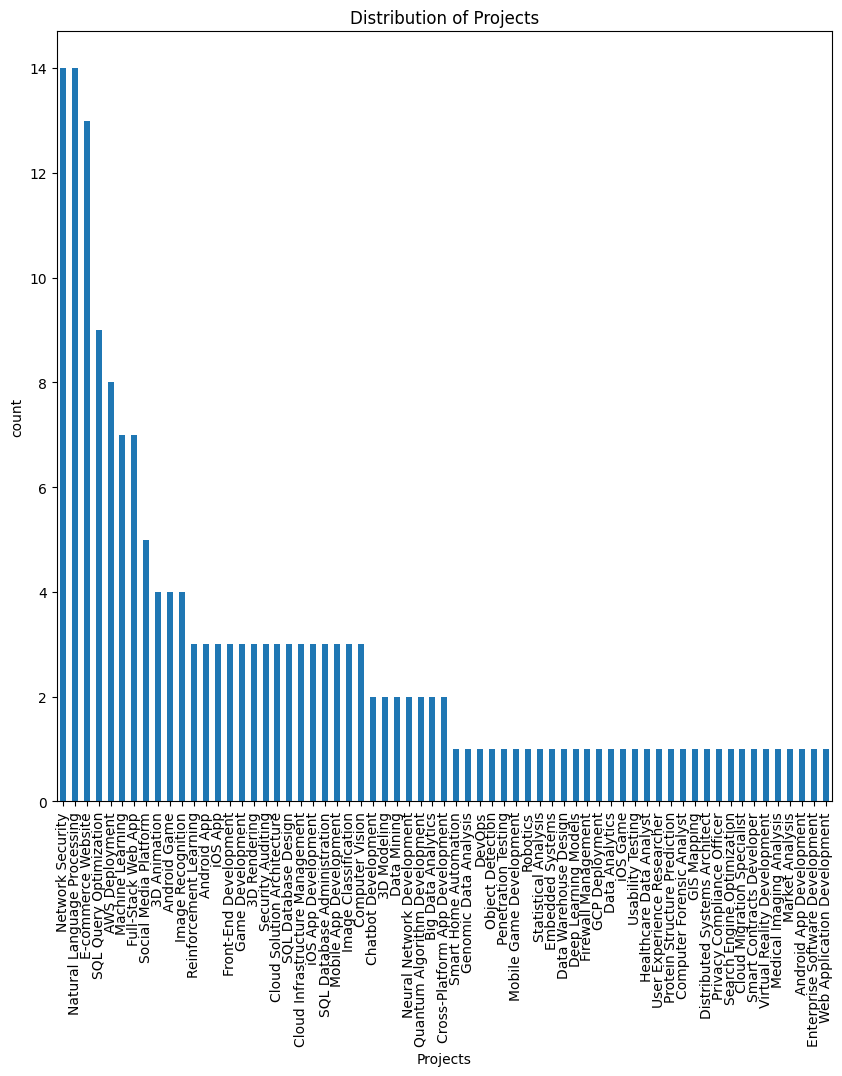

In [ ]:
student['Projects'].value_counts().plot(kind='bar', title='Distribution of Projects', figsize=(10, 10))
plt.xlabel('Projects')
plt.ylabel('count')
plt.show()

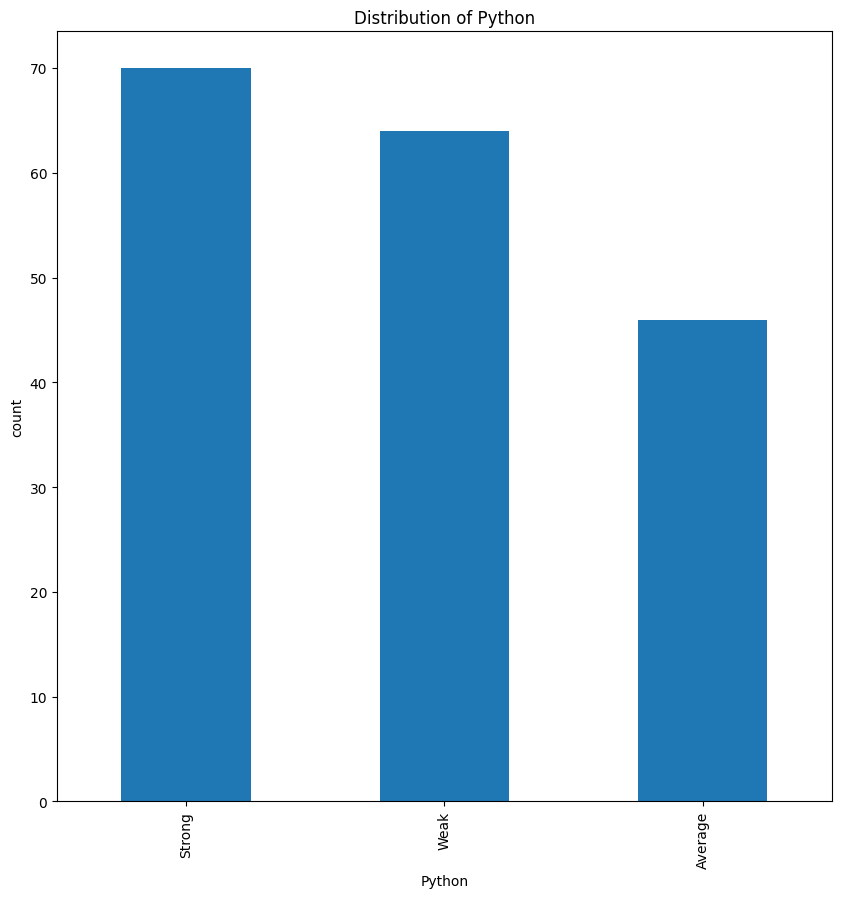

In [ ]:
student['Python'].value_counts().plot(kind='bar', title='Distribution of Python', figsize=(10, 10))
plt.xlabel('Python')
plt.ylabel('count')
plt.show()

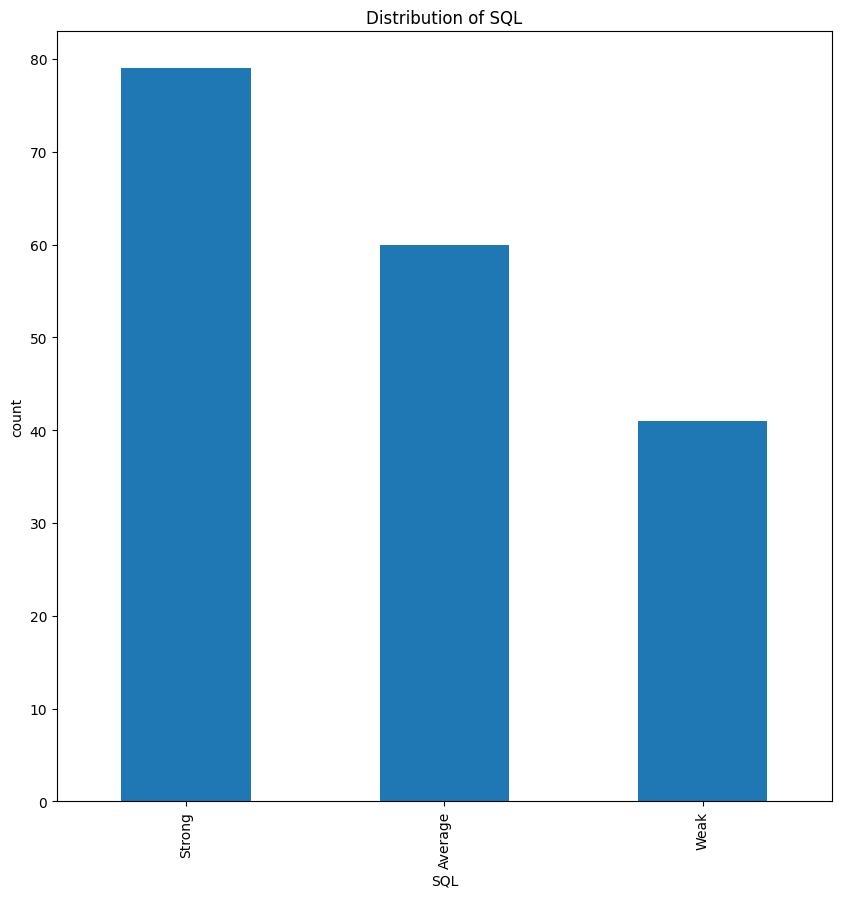

In [ ]:
student['SQL'].value_counts().plot(kind='bar', title='Distribution of SQL', figsize=(10, 10))
plt.xlabel('SQL')
plt.ylabel('count')
plt.show()

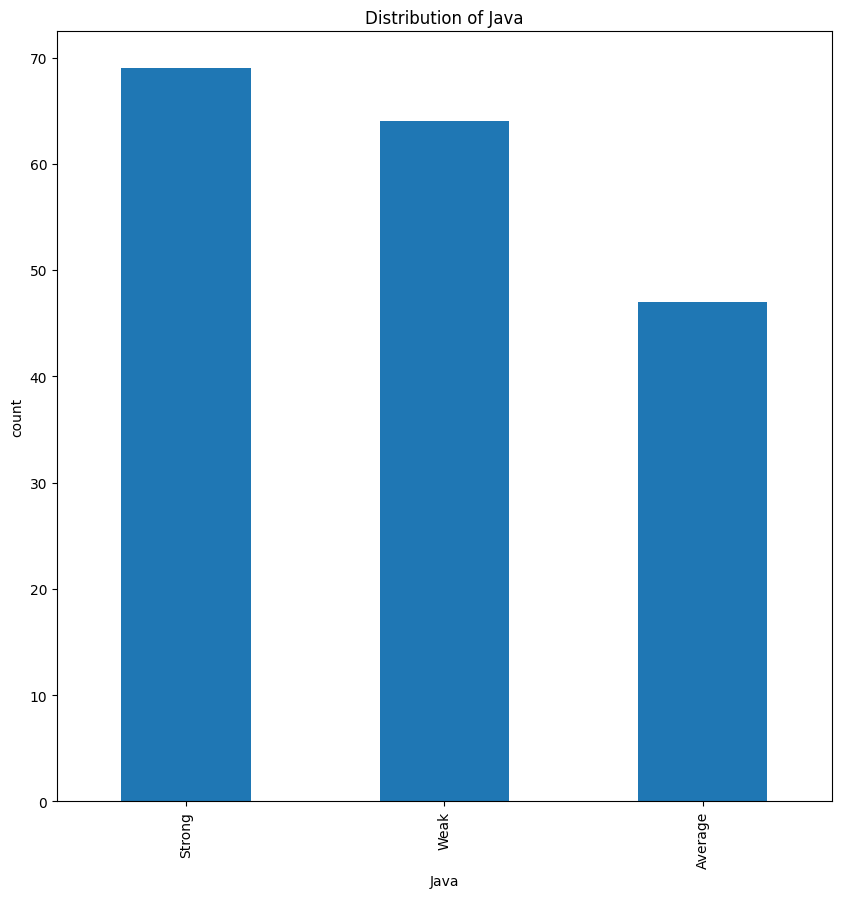

In [ ]:
student['Java'].value_counts().plot(kind='bar', title='Distribution of Java', figsize=(10, 10))
plt.xlabel('Java')
plt.ylabel('count')
plt.show()

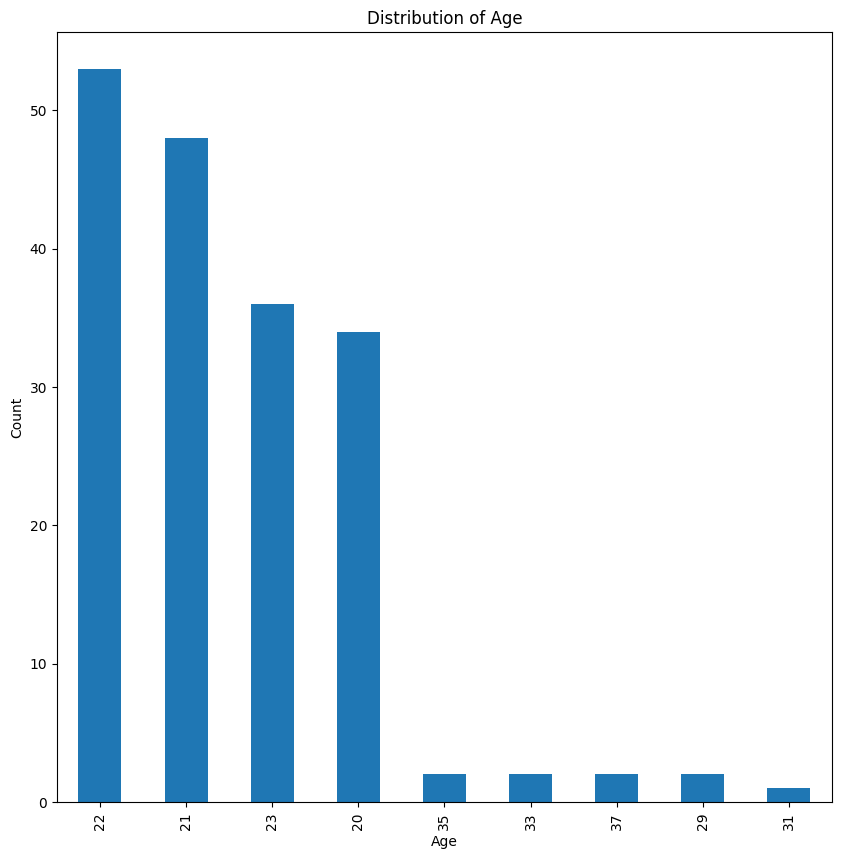

In [ ]:
student['Age'].value_counts().plot(kind='bar', title='Distribution of Age', figsize=(10, 10))
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

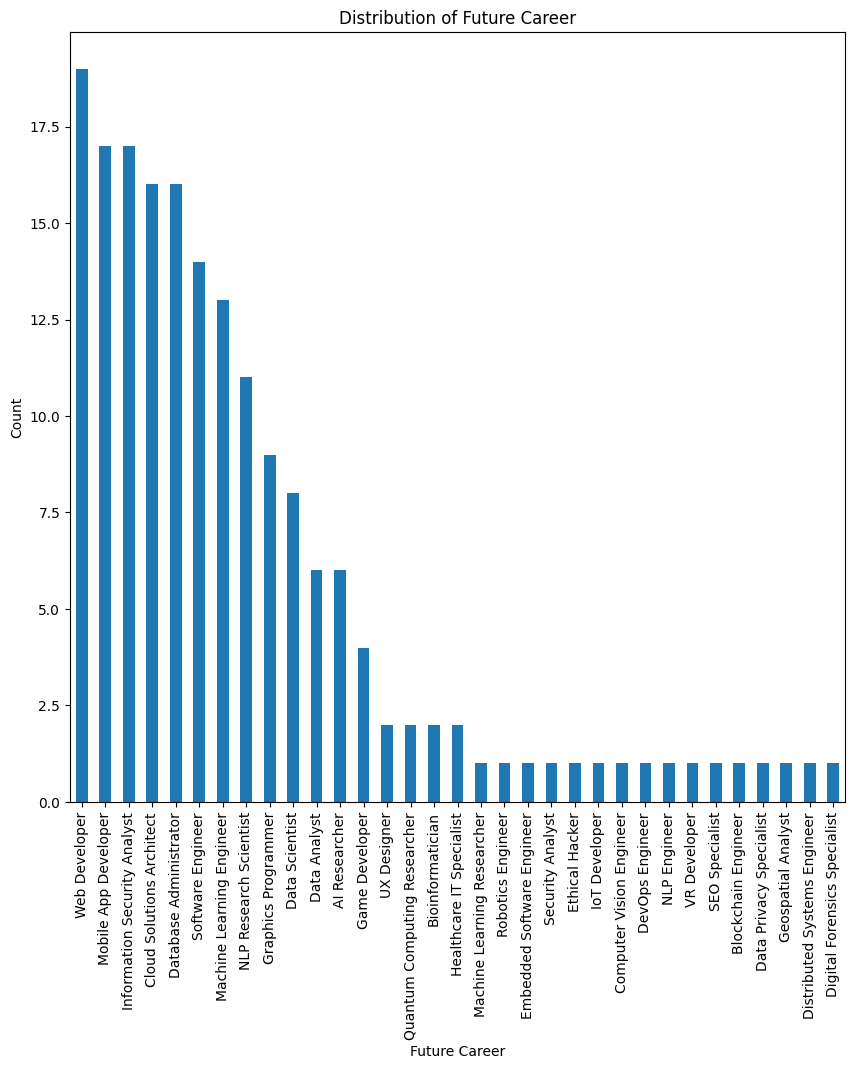

In [ ]:
student['Future Career'].value_counts().plot(kind='bar', title='Distribution of Future Career', figsize=(10, 10))
plt.xlabel('Future Career')
plt.ylabel('Count')
plt.show()

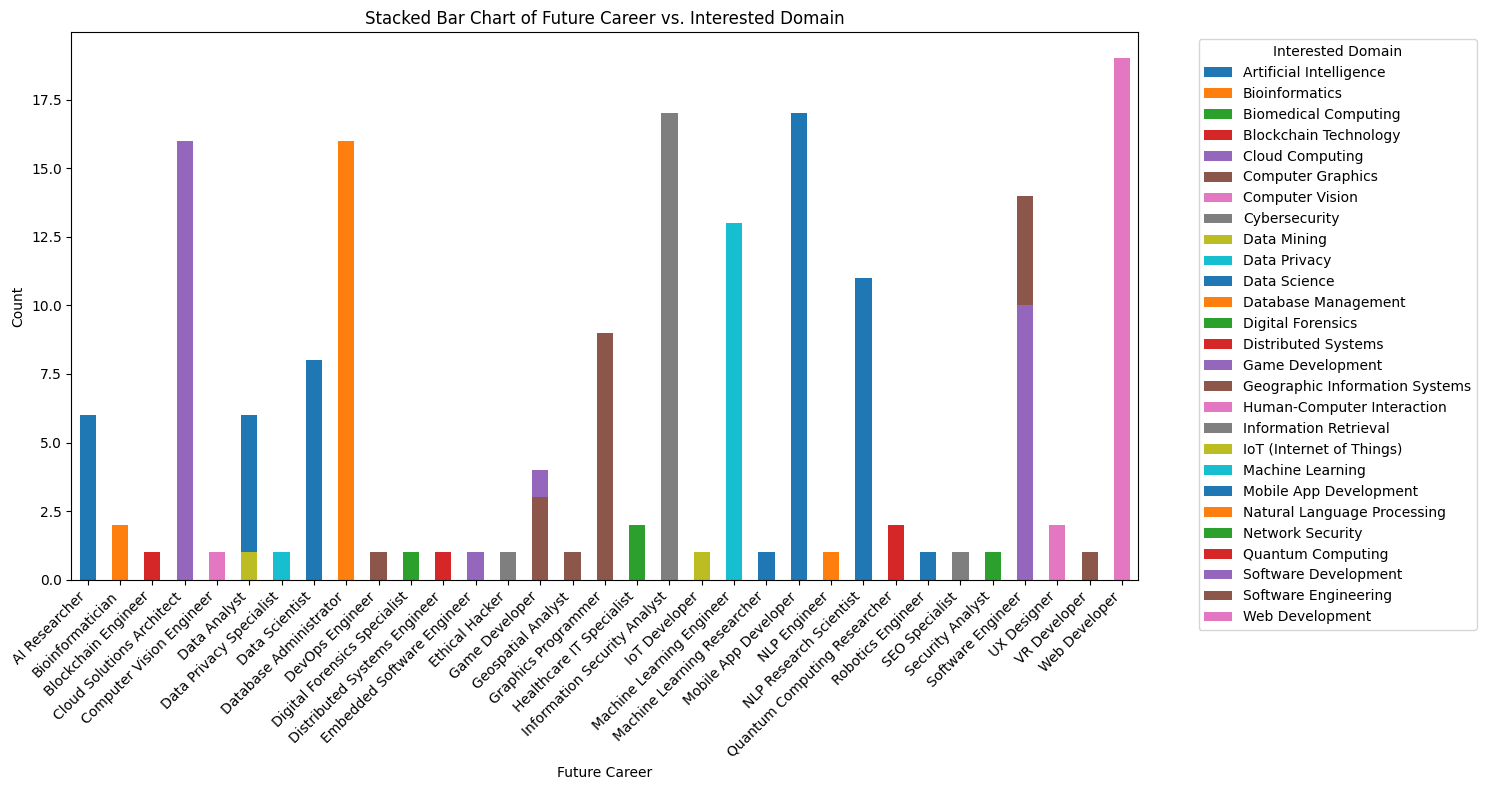

In [ ]:


# Calculate the frequency of each combination
career_domain_crosstab = pd.crosstab(student['Future Career'], student['Interested Domain'])

# Create a stacked bar chart
career_domain_crosstab.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Stacked Bar Chart of Future Career vs. Interested Domain')
plt.xlabel('Future Career')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Interested Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

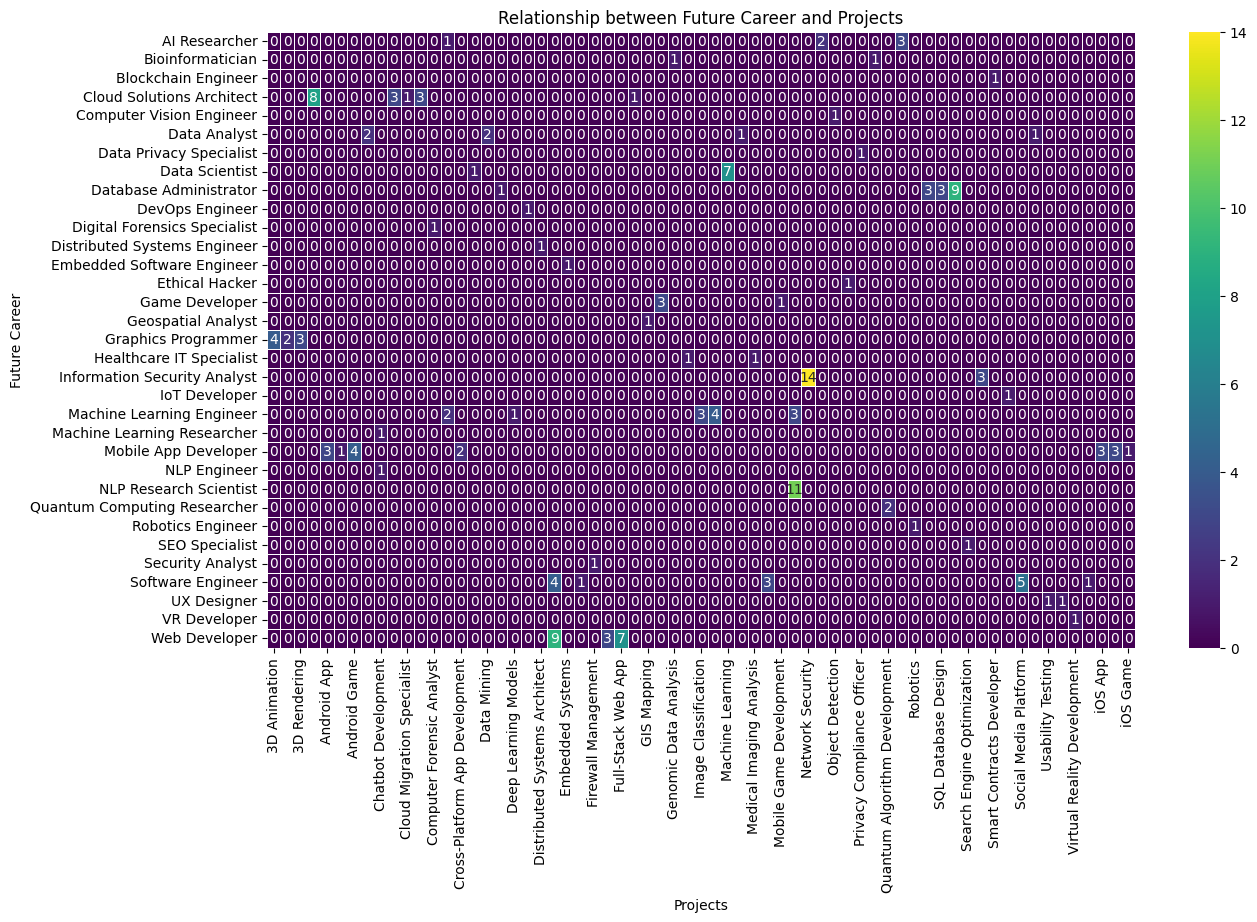

In [ ]:
# Calculate the frequency of each combination of 'Future Career' and 'Interested Domain'
career_domain_crosstab = pd.crosstab(student['Future Career'], student['Projects'])

# Create a heatmap to visualize the relationship
plt.figure(figsize=(14, 8))
sns.heatmap(career_domain_crosstab, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Relationship between Future Career and Projects')
plt.xlabel('Projects')
plt.ylabel('Future Career')
plt.show()

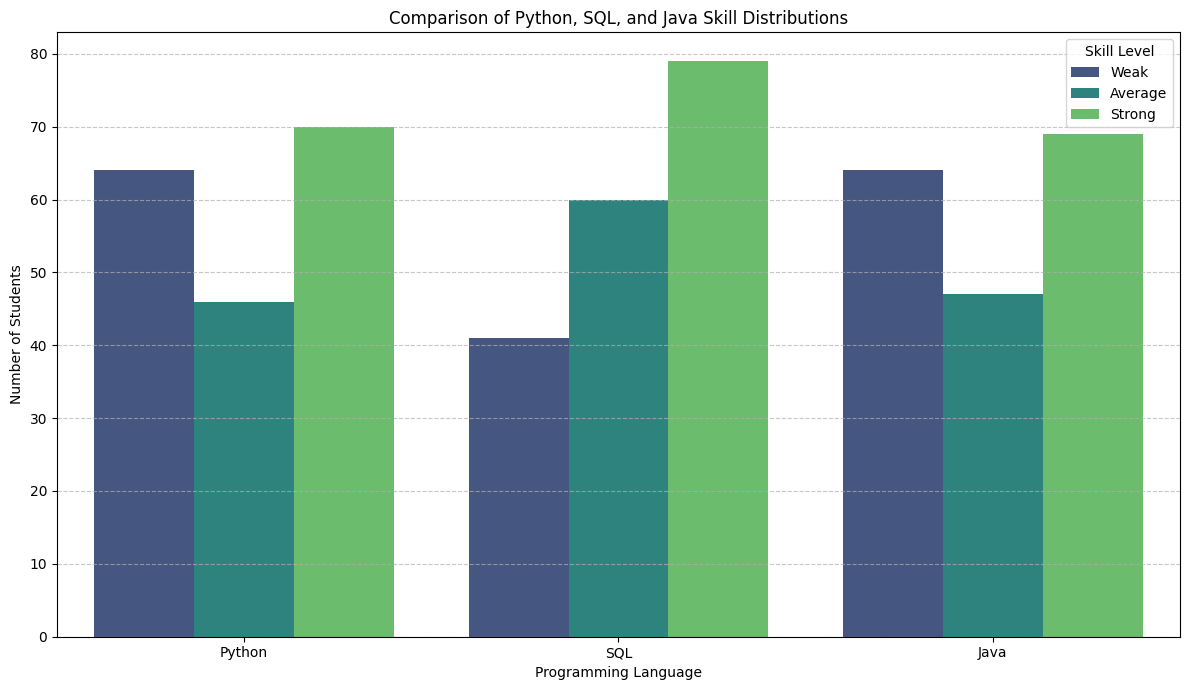

In [ ]:
# Get value counts for each skill
python_skills = student['Python'].value_counts().reset_index()
python_skills.columns = ['Skill_Level', 'Count']
python_skills['Language'] = 'Python'

sql_skills = student['SQL'].value_counts().reset_index()
sql_skills.columns = ['Skill_Level', 'Count']
sql_skills['Language'] = 'SQL'

java_skills = student['Java'].value_counts().reset_index()
java_skills.columns = ['Skill_Level', 'Count']
java_skills['Language'] = 'Java'

# Combine all skill data into a single DataFrame
all_skills = pd.concat([python_skills, sql_skills, java_skills])

# Define a consistent order for skill levels
skill_level_order = ['Weak', 'Average', 'Strong']
all_skills['Skill_Level'] = pd.Categorical(all_skills['Skill_Level'], categories=skill_level_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=all_skills, x='Language', y='Count', hue='Skill_Level', palette='viridis')
plt.title('Comparison of Python, SQL, and Java Skill Distributions')
plt.xlabel('Programming Language')
plt.ylabel('Number of Students')
plt.legend(title='Skill Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

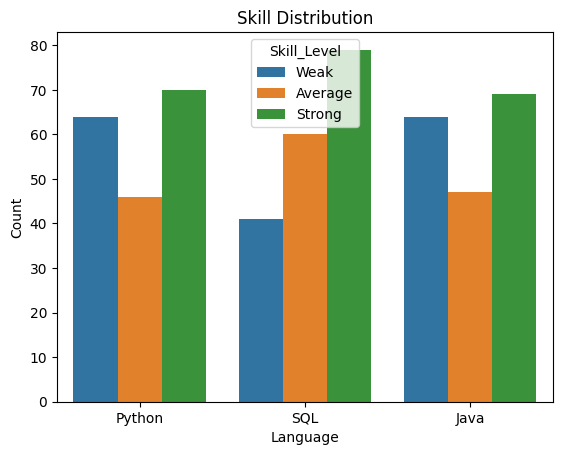

In [ ]:
# Combine skill counts in one go
all_skills = pd.concat([
    student[col].value_counts().rename_axis('Skill_Level').reset_index(name='Count').assign(Language=col)
    for col in ['Python', 'SQL', 'Java']
])

# Order skill levels
all_skills['Skill_Level'] = pd.Categorical(all_skills['Skill_Level'], ['Weak','Average','Strong'])

# Plot
sns.barplot(data=all_skills, x='Language', y='Count', hue='Skill_Level')
plt.title('Skill Distribution')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [ ]:
# Encode categorical columns
for col in student.columns:
    if student[col].dtype == 'object':
        student[col] = LabelEncoder().fit_transform(student[col])


In [ ]:
from sklearn.model_selection import train_test_split

# Correctly unpack the 4 outputs from train_test_split
X = student.drop(columns=['Future Career'])
y = to_categorical(student['Future Career'])

train_data, test_data, train_targets, test_targets = train_test_split(X, y, test_size=0.2, random_state=42)
#feature normalization
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std


In [ ]:
from tensorflow.keras import layers
import keras
model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

In [ ]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

In [ ]:
model.fit(train_data, train_targets,epochs=130, batch_size=16, verbose=0)

In [ ]:
test_mse_score = model.evaluate(test_data, test_targets)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0310 - mae: 0.0747 
